# The recap

Built from [`ROADMAP_ANNUAL_RECAP.md`](../ROADMAP_ANNUAL_RECAP.md) and [`ANNUAL_RECAP.md`](../ANNUAL_RECAP.md), the layout decisions written before this project's rendering function, following the roadmap's own Phase 3 recommendation since this is the first project in the portfolio that composes several elements into one figure rather than one chart type.

This notebook loads two artifacts already computed by [`hansard-pm-nlp`](https://github.com/RedaAllab/hansard-pm-nlp): `event_study_dataset.parquet` (Phase 7, word volume and net certainty) and `lda_topics.parquet` (Phase 5, topic weights). No model is retrained and no per-document text is reprocessed.

In [1]:
from pathlib import Path

from hansard_pm_portfolio import data_access as da
from hansard_pm_portfolio.viz import annual_recap as viz
from hansard_pm_portfolio.viz.common import plot_banner, save

ASSETS_DIR = Path("../portfolio/04_annual_recap/assets")
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

## 0. README banner

In [2]:
fig = plot_banner("The recap", "hansard-pm-portfolio, project 04")
save(fig, ASSETS_DIR / "banner.png")
fig

<Figure size 800x200 with 0 Axes>

<Figure size 800x200 with 0 Axes>

## 1. Phase 0: the join-key check

`ROADMAP_ANNUAL_RECAP.md`'s own Phase 0 flags a real risk: the corpus's layers were built by 4 different scripts, and nothing in the documentation guarantees they share a join key. Checked directly (`ANNUAL_RECAP.md` section 1): `event_study_dataset.parquet` and `lda_topics.parquet` join on `(pm_name, sitting_date)` with 296/296 rows matching on both sides. This project is built on those two files alone, both already reused unchanged in projects 02 and 03, rather than on Phase 3/4's whole-PM aggregates.

In [3]:
events = da.load_event_study_dataset()
topics = da.load_topic_weights()
merged = events.merge(topics, on=["pm_name", "sitting_date"], how="inner")
print(f"events: {len(events)} rows, topics: {len(topics)} rows, "
      f"inner join: {len(merged)} rows")
assert len(merged) == len(events) == len(topics), (
    "join key mismatch, see ANNUAL_RECAP.md section 1"
)
start, end = events["sitting_date"].min().date(), events["sitting_date"].max().date()
print(f"corpus span: {start} to {end}")

events: 296 rows, topics: 296 rows, inner join: 296 rows
corpus span: 2019-07-25 to 2026-07-15


## 2. Build the annual recap table

The 4 fixed indicators locked in `ANNUAL_RECAP.md` section 2: PM tenure segments, word volume (sum), dominant theme (yearly argmax of topic weight, T0+T1 merged), and tone (mean `net_certainty`, the same style metric already used in projects 01 and 03 rather than a new "tone" metric).

Two years turn out to be partial: 2019 (corpus starts in July) was anticipated by the roadmap; **2026 is partial too**, because the corpus extraction cuts off in July, not because the year ended - found in Phase 0, not anticipated in the roadmap's own text.

In [4]:
tenures = da.load_pm_tenures()
recap = da.build_annual_recap(events, topics, tenures)
recap[["year", "word_count", "net_certainty", "dominant_theme", "is_partial_year"]]

,year,word_count,net_certainty,dominant_theme,is_partial_year
0,2019,79913,0.004767,Brexit and the Northern Ireland deal,True
1,2020,163424,0.007610,Covid-19: restrictions and testing,False
2,2021,160541,0.003091,Covid-19: NHS and public inquiry,False
3,2022,155897,0.006176,Covid-19: NHS and public inquiry,False
4,2023,121320,0.007137,Budget and domestic policy,False
5,2024,122103,0.008484,Budget and domestic policy,False
6,2025,134710,0.008666,Budget and domestic policy,False
7,2026,92670,0.009554,Budget and domestic policy,True


## 3. The main visual: header frieze + 8 year-cards

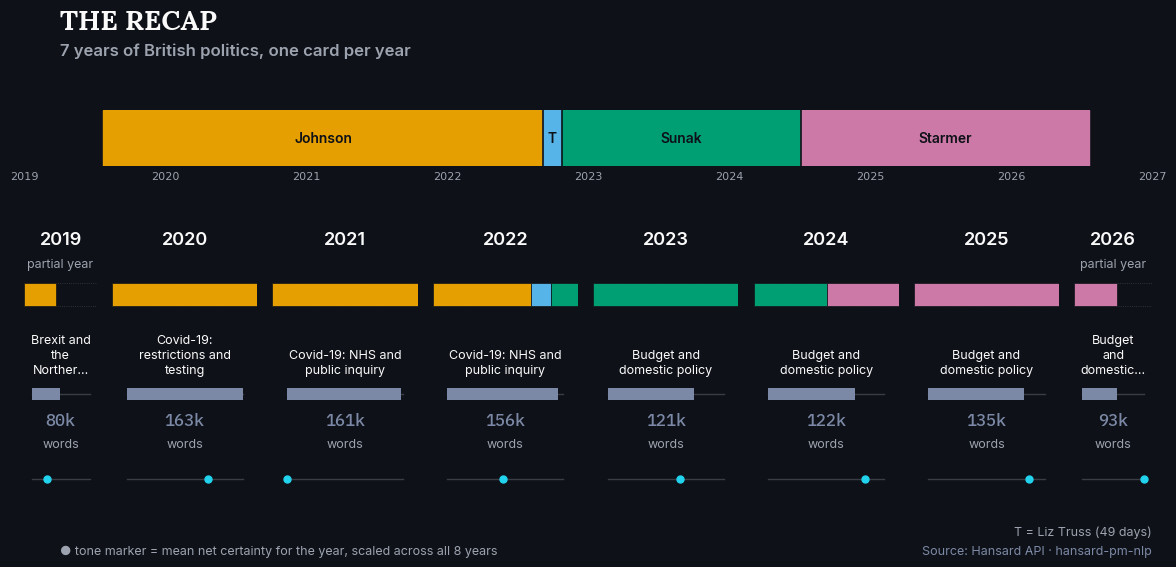

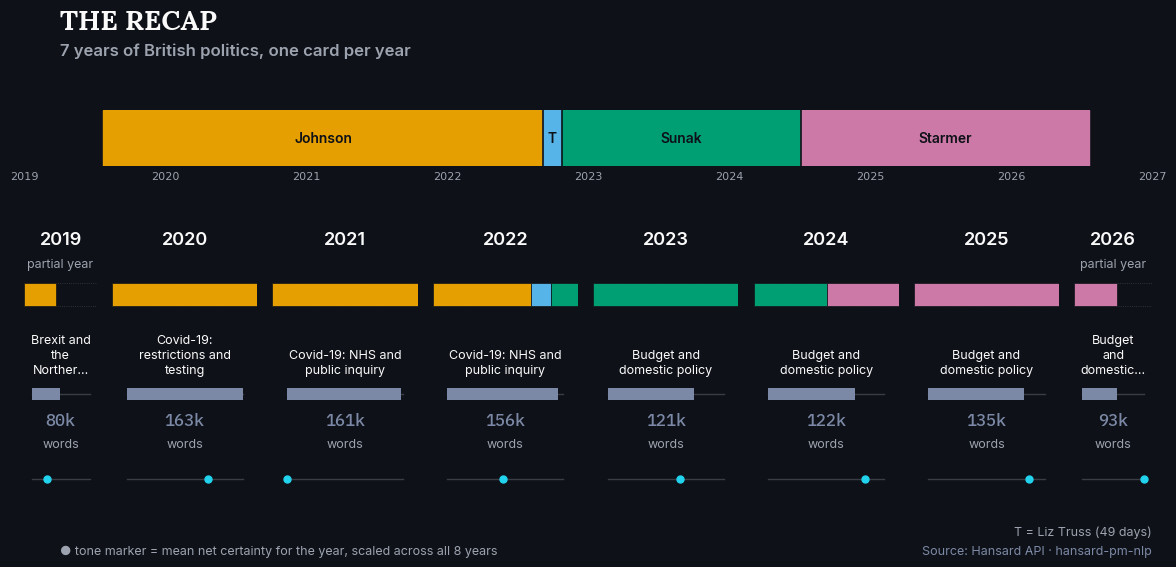

In [5]:
fig = viz.plot_annual_recap(recap, tenures)
save(fig, ASSETS_DIR / "annual_recap_main.png")
fig

## Links

- Execution plan: [`ROADMAP_ANNUAL_RECAP.md`](../ROADMAP_ANNUAL_RECAP.md)
- Layout decisions: [`ANNUAL_RECAP.md`](../ANNUAL_RECAP.md)
- Source tables: [`event_study_dataset.parquet`](https://github.com/RedaAllab/hansard-pm-nlp/tree/main/data/processed) and [`lda_topics.parquet`](https://github.com/RedaAllab/hansard-pm-nlp/tree/main/data/processed) (in `hansard-pm-nlp`)
- Architecture decisions: [`ARCHITECTURE.md`](../ARCHITECTURE.md)
- Project README: [`portfolio/04_annual_recap/README.md`](../portfolio/04_annual_recap/README.md)
- For the monthly-level detail this project summarizes: [project 02, the thematic heatmap](../portfolio/02_topic_heatmap/README.md) and [project 01, the style duel](../portfolio/01_style_duel/README.md)